# 03. Modelos de Machine Learning

# Importando as Bibliotecas

In [1]:
# ================================
# Utilitários
# ================================
import time
import joblib

# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Divisão, validação e otimização
# ================================
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# ================================
# Interpretabilidade
# ================================
import shap

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 2. Leitura da Base de Dados

In [6]:
dados = pd.read_csv("../data/dados_modelo.csv", index_col=0)
dados.head()

,inadimplente_2_anos,utilizacao_credito,idade,atrasos_30_59_dias,razao_divida,renda_mensal,linhas_credito_abertas,atrasos_90_dias,emprestimos_imobiliarios,atrasos_60_89_dias,numero_dependentes,total_atrasos,atraso_grave
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,1
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,0


# 3. Validação rápida dos Dados

In [7]:
print(f"Total Linhas -> {dados.shape[0]}")
print(f"Total Colunas -> {dados.shape[1]}")
print(f"\n===== Informações dos dados =====\n")
print(dados.info())

Total Linhas -> 149999
Total Colunas -> 13

===== Informações dos dados =====

<class 'pandas.DataFrame'>
Index: 149999 entries, 1 to 150000
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   inadimplente_2_anos       149999 non-null  int64  
 1   utilizacao_credito        149999 non-null  float64
 2   idade                     149999 non-null  int64  
 3   atrasos_30_59_dias        149999 non-null  int64  
 4   razao_divida              149999 non-null  float64
 5   renda_mensal              120268 non-null  float64
 6   linhas_credito_abertas    149999 non-null  int64  
 7   atrasos_90_dias           149999 non-null  int64  
 8   emprestimos_imobiliarios  149999 non-null  int64  
 9   atrasos_60_89_dias        149999 non-null  int64  
 10  numero_dependentes        146075 non-null  float64
 11  total_atrasos             149999 non-null  int64  
 12  atraso_grave              149999 non-

# 4. Definição da Variável Alvo + Separação de Treino

In [8]:
X = dados.drop("inadimplente_2_anos", axis=1)

y = dados["inadimplente_2_anos"]

In [11]:
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_treino, X_val, y_treino, y_val = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.20, random_state=42)

In [12]:
print(f"Treino -> {len(X_treino)}")
print(f"Validação -> {len(X_val)}")
print(f"Teste -> {len(X_teste)}")

Treino -> 95999
Validação -> 24000
Teste -> 30000


# 5. Pré-Processamento dos Dados

In [15]:
var_numericas = dados.select_dtypes(include="number").columns.difference(["inadimplente_2_anos"]).tolist()

In [16]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [18]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, var_numericas)
    ]
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_val_tratado = preprocessador.transform(X_val)
X_teste_tratado = preprocessador.transform(X_teste)

In [19]:
num_cols = list(var_numericas)

X_treino = pd.DataFrame(X_treino_tratado, columns= num_cols)
X_val = pd.DataFrame(X_val_tratado, columns=num_cols)
X_teste = pd.DataFrame(X_teste_tratado, columns=num_cols)

In [20]:
X_treino.head()

,atraso_grave,atrasos_30_59_dias,atrasos_60_89_dias,atrasos_90_dias,emprestimos_imobiliarios,idade,linhas_credito_abertas,numero_dependentes,razao_divida,renda_mensal,total_atrasos,utilizacao_credito
0,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,0.182305,1.263835,2.048514,-0.177313,0.437743,-0.07449,-0.027710
1,-0.242914,-0.100251,-0.05813,-0.064006,0.871170,-0.495829,-0.091894,0.239108,-0.177252,0.156936,-0.07449,-0.026546
2,-0.242914,-0.100251,-0.05813,-0.064006,0.871170,-1.377402,-0.672921,-0.665595,-0.176882,-0.340164,-0.07449,-0.026807
3,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,1.199505,-0.479245,-0.665595,0.462815,-0.086860,-0.07449,-0.027280
4,-0.242914,-0.100251,-0.05813,-0.064006,-0.015893,-0.292389,0.295457,-0.665595,-0.177225,-0.143905,-0.07449,-0.027266


# 6. Aplicação do VarianceThreshold

In [22]:
selector_variance = VarianceThreshold(threshold=0.05)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_val_variance = selector_variance.transform(X_val)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print(f"\nFeatures mantidas:")
print(features_variance.tolist())

Features Originais -> 12
Features Selecionadas -> 12

Features mantidas:
['atraso_grave', 'atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias', 'emprestimos_imobiliarios', 'idade', 'linhas_credito_abertas', 'numero_dependentes', 'razao_divida', 'renda_mensal', 'total_atrasos', 'utilizacao_credito']


# 7. Treinamento e comparação inicial dos Modelos

In [23]:
negativos = (y == 0).sum()
positivos = (y == 1).sum()

scale_pos_weight = negativos / positivos

scale_pos_weight

np.float64(13.96100139636944)

In [31]:
modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": xgb.XGBClassifier(max_depth=5, n_estimators=300, random_state=42, scale_pos_weight=scale_pos_weight),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=5, random_state=42, class_weight="balanced", verbose=-1)
}

In [32]:
def calcula_metricas(y_val, y_pred):
    acuracia = accuracy_score(y_val, y_pred)
    precision_0 = precision_score(y_val, y_pred, pos_label=0)
    precision_1 = precision_score(y_val, y_pred, pos_label=1)
    recall_0 = recall_score(y_val, y_pred, pos_label=0)
    recall_1 = recall_score(y_val, y_pred, pos_label=1)
    f1_macro = f1_score(y_val, y_pred, average="macro")

    return {
        "Accuracy": acuracia,
        "Precision_0": precision_0,
        "Precision_1": precision_1,
        "Recall_0": recall_0,
        "Recall_1": recall_1,
        "F1_Macro": f1_macro
    }

In [33]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Modelo"] = nome

    resultados.append(metricas)

resultados = pd.DataFrame(resultados)
resultados = resultados.sort_values(by="F1_Macro", ascending=False).round(3)
resultados

,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_Macro,Modelo
4,0.838,0.972,0.241,0.851,0.661,0.630,XGBoost
2,0.825,0.977,0.238,0.832,0.729,0.629,Random Forest
5,0.814,0.978,0.227,0.818,0.746,0.620,LightGBM
0,0.834,0.968,0.226,0.850,0.610,0.618,Regressao Logistica
3,0.934,0.944,0.525,0.989,0.176,0.615,KNN
1,0.753,0.982,0.187,0.749,0.805,0.577,Árvore de Decisão


In [36]:
for nome in["XGBoost", "Random Forest", "LightGBM"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    print(f"Modelo: {nome}")
    print(classification_report(y_val, previsao))
    print('-'*60)

Modelo: XGBoost
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     22396
           1       0.24      0.66      0.35      1604

    accuracy                           0.84     24000
   macro avg       0.61      0.76      0.63     24000
weighted avg       0.92      0.84      0.87     24000

------------------------------------------------------------
Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     22396
           1       0.24      0.73      0.36      1604

    accuracy                           0.83     24000
   macro avg       0.61      0.78      0.63     24000
weighted avg       0.93      0.83      0.86     24000

------------------------------------------------------------
Modelo: LightGBM
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     22396
           1       0.23      0.75      0.35      1604

    a

# 8. Otimização de Hiperparametros

In [43]:
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
gbm_model = LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)

In [46]:
scorer_recall_1 = make_scorer(recall_score, pos_label=1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [47]:
# XGBoost - Otimização
param_xgb = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.5, 1],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

busca_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_xgb,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

busca_xgb.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_xgb.best_score_}")
print(f"\nMelhores Params -> {busca_xgb.best_params_}")

Melhor Score -> 0.7743493844475612

Melhores Params -> {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}


In [48]:
param_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
}

busca_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_rf,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

busca_rf.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_rf.best_score_}")
print(f"Melhores Hiperparametros -> {busca_rf.best_params_}")

Melhor Score -> 0.7338320087268193
Melhores Hiperparametros -> {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10}


In [50]:
param_lgbm = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 45],
    "max_depth": [5, 10, -1],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

busca_gbm = RandomizedSearchCV(
    estimator=gbm_model,
    param_distributions=param_lgbm,
    n_iter=15,
    scoring=scorer_recall_1,
    cv=cv,
    random_state=42
)

busca_gbm.fit(X_treino, y_treino)

print(f"Melhor Score -> {busca_gbm.best_score_}")
print(f"Melhores Hiperparametros -> {busca_gbm.best_params_}")

Melhor Score -> 0.7632850241545893
Melhores Hiperparametros -> {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 600, 'min_child_samples': 100, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


# 9. Resultados após a otimização

In [52]:
modelos_tunados = {
    "XGBoost Tunado": busca_xgb.best_estimator_,
    "Random Forest Tunado": busca_rf.best_estimator_,
    "LightGBM Tunado": busca_gbm.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsao)

    metricas["Modelo"] = nome

    resultados_tuning.append(metricas)

resultados_tuning = pd.DataFrame(resultados_tuning)
resultados_tuning = resultados_tuning.sort_values(by="Recall_1", ascending=False)
resultados_tuning

,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_Macro,Modelo
0,0.793833,0.981298,0.215356,0.794204,0.788653,0.608110,XGBoost Tunado
2,0.799083,0.980374,0.218115,0.800723,0.776185,0.611012,LightGBM Tunado
1,0.814333,0.979474,0.230537,0.818182,0.760599,0.622710,Random Forest Tunado


## Matriz de Confusão - Modelos Otimizados

In [53]:
modelo_xgb_tunado = busca_xgb.best_estimator_
modelo_rf_tunado = busca_rf.best_estimator_
modelo_gbm_tunado = busca_gbm.best_estimator_

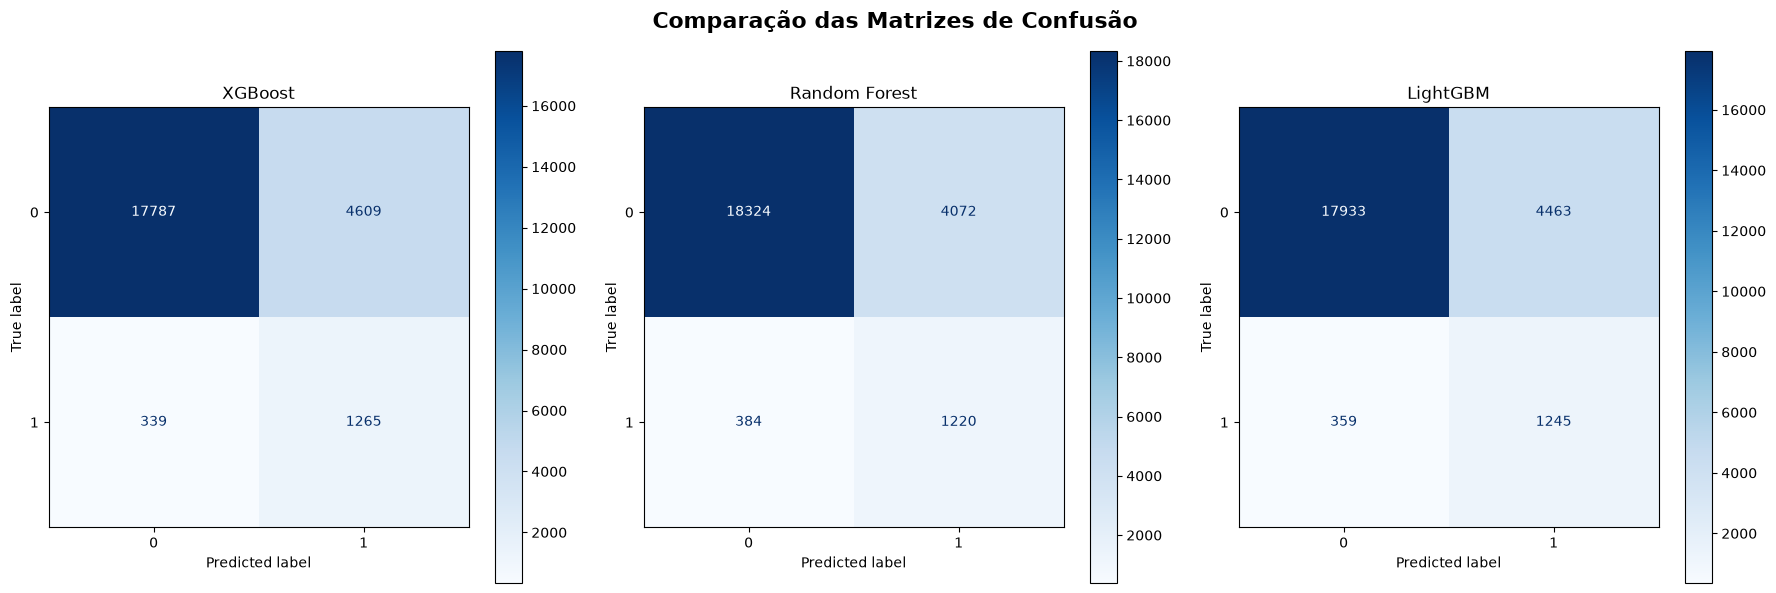

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

ConfusionMatrixDisplay.from_estimator(modelo_xgb_tunado, X_val, y_val, cmap="Blues", ax=axes[0])
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay.from_estimator(modelo_rf_tunado, X_val, y_val, cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_estimator(modelo_gbm_tunado, X_val, y_val, cmap="Blues", ax=axes[2])
axes[2].set_title("LightGBM")

plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Análise Curva ROC - Modelos Otimizados

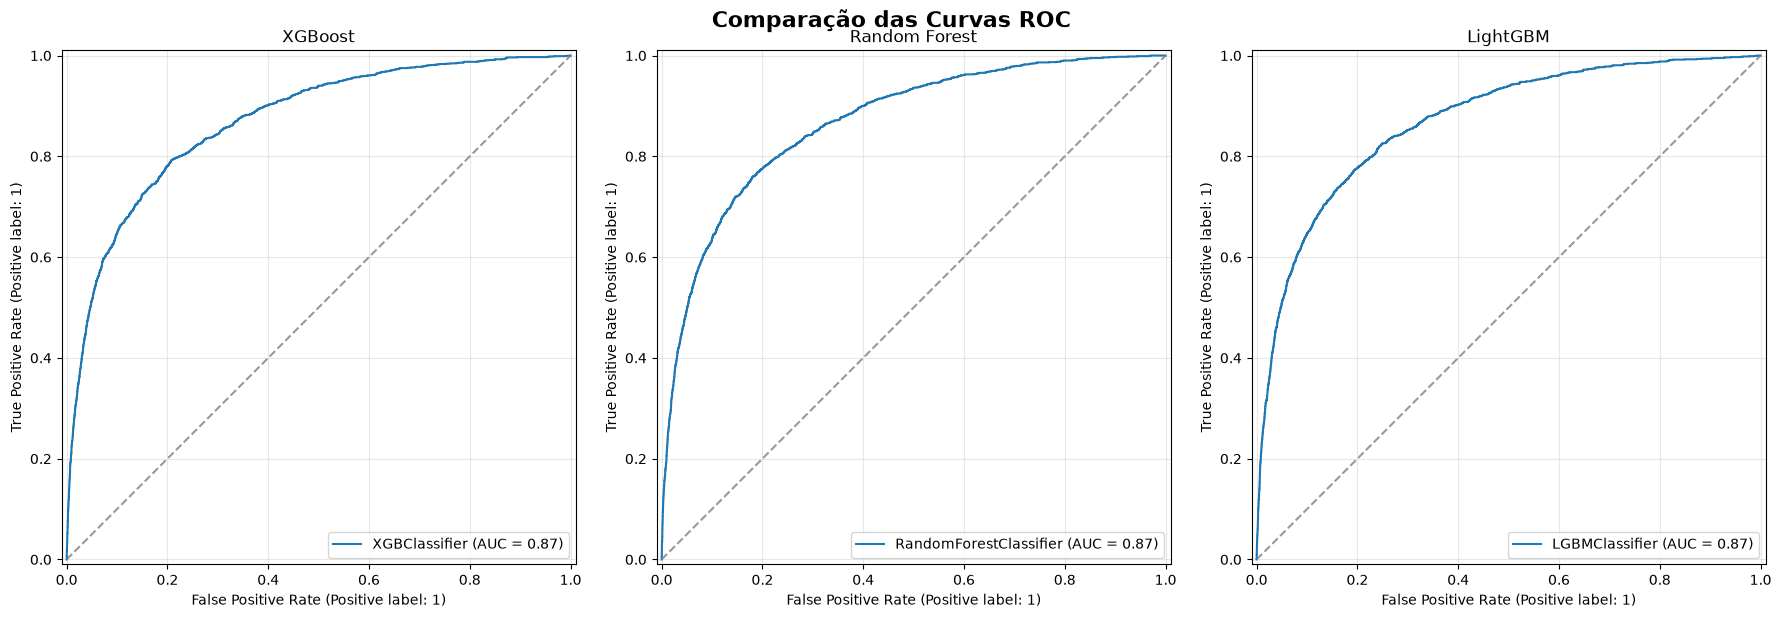

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

RocCurveDisplay.from_estimator(modelo_xgb_tunado, X_val, y_val, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[0].set_title("XGBoost")
axes[0].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_rf_tunado, X_val, y_val, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[1].set_title("Random Forest")
axes[1].grid(alpha=0.3)

RocCurveDisplay.from_estimator(modelo_gbm_tunado, X_val, y_val, ax=axes[2])
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[2].set_title("LightGBM")
axes[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# 10. Modelos Ensemble - Voting e Stacking

## Modelo Voting Classifier

In [57]:
modelo_voting = VotingClassifier(
    estimators=[
        ("xgboost", modelo_xgb_tunado),
        ("lightgbm", modelo_gbm_tunado)
    ],
    voting="soft",
    n_jobs=-1
)

In [58]:
modelo_voting.fit(X_treino, y_treino)

pred_voting = modelo_voting.predict(X_val)

In [59]:
print("===== Modelo Voting Classifier =====")
print(classification_report(y_val, pred_voting))

===== Modelo Voting Classifier =====
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     22396
           1       0.22      0.78      0.34      1604

    accuracy                           0.80     24000
   macro avg       0.60      0.79      0.61     24000
weighted avg       0.93      0.80      0.84     24000



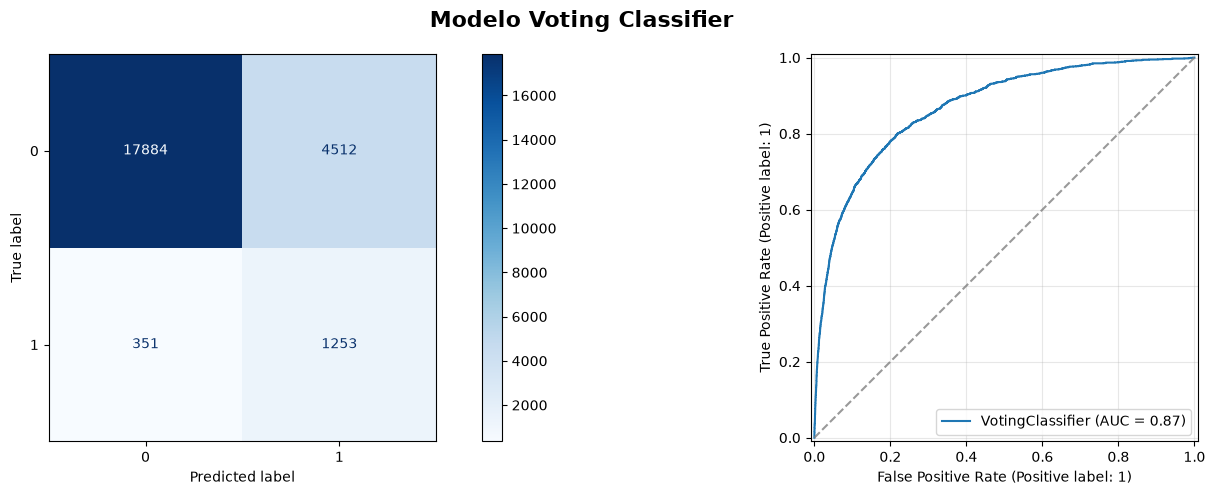

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

ConfusionMatrixDisplay.from_estimator(modelo_voting, X_val, y_val, cmap="Blues", ax=axes[0])

RocCurveDisplay.from_estimator(modelo_voting, X_val, y_val, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
axes[1].grid(alpha=0.3)

plt.suptitle("Modelo Voting Classifier", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Modelo Stacking Classifier